In [6]:
#====================================
#
# Linear Regression Model
#
# MLOps Project
#
# Pablo Rodriguez
#
#

In [7]:
import json
from pathlib import Path
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [8]:
ARTIFACT_DIR = Path("linear_regression_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

rng = np.random.default_rng(42)

In [9]:
N = 500

data = pd.DataFrame({
    "years_experience": rng.uniform(0, 15, N),
    "education_years": rng.integers(12, 21, N),
    "certifications": rng.integers(0, 7, N),
    "projects_completed": rng.integers(0, 31, N)
})

noise = rng.normal(
    0,
    5000,
    N
)

data["salary"] = (
    28000
    + 4200 * data["years_experience"]
    + 1800 * data["education_years"]
    + 1400 * data["certifications"]
    + 350 * data["projects_completed"]
    + noise
)

data.head()

,years_experience,education_years,certifications,projects_completed,salary
0,11.609341,19,3,27,111350.689384
1,6.583177,18,1,1,82909.295320
2,12.878969,17,1,12,109238.575555
3,10.460520,19,2,14,102585.266941
4,1.412660,13,4,24,65356.378045


In [10]:
print("Rows:", len(data))

print(
    "Missing values:",
    data.isna().sum().sum()
)

assert len(data) == 500
assert data.isna().sum().sum() == 0

Rows: 500
Missing values: 0


In [11]:
FEATURES = [
    "years_experience",
    "education_years",
    "certifications",
    "projects_completed"
]

TARGET = "salary"

X = data[FEATURES]
y = data[TARGET]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(
    "Training examples:",
    len(X_train)
)

print(
    "Test examples:",
    len(X_test)
)

Training examples: 400
Test examples: 100


In [13]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

print("Model trained.")

Model trained.


In [14]:
coefficients = pd.DataFrame({
    "feature": FEATURES,
    "coefficient": model.coef_
})

coefficients

,feature,coefficient
0,years_experience,4305.426652
1,education_years,1848.003499
2,certifications,1478.984504
3,projects_completed,346.899158


In [15]:
test_predictions = model.predict(
    X_test
)

test_predictions[:5]

array([ 66699.94776364,  81394.80292784,  81388.3920828 , 107367.43093673,
       111385.84309617])

In [16]:
MAE = mean_absolute_error(
    y_test,
    test_predictions
)

RMSE = np.sqrt(
    mean_squared_error(
        y_test,
        test_predictions
    )
)

R2 = r2_score(
    y_test,
    test_predictions
)

metrics = {
    "MAE": MAE,
    "RMSE": RMSE,
    "R2": R2
}

metrics

{'MAE': 4838.674322718933,
 'RMSE': np.float64(5900.701401915544),
 'R2': 0.9152905061401905}

In [17]:
print(
    f"MAE:  ${MAE:,.2f}"
)

print(
    f"RMSE: ${RMSE:,.2f}"
)

print(
    f"R²:   {R2:.3f}"
)

MAE:  $4,838.67
RMSE: $5,900.70
R²:   0.915


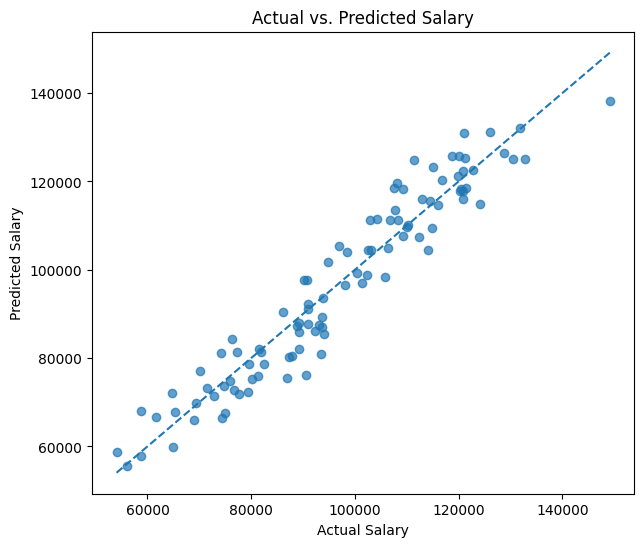

In [18]:
plt.figure(
    figsize=(7, 6)
)

plt.scatter(
    y_test,
    test_predictions,
    alpha=0.7
)

minimum = min(
    y_test.min(),
    test_predictions.min()
)

maximum = max(
    y_test.max(),
    test_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel(
    "Actual Salary"
)

plt.ylabel(
    "Predicted Salary"
)

plt.title(
    "Actual vs. Predicted Salary"
)

plt.show()

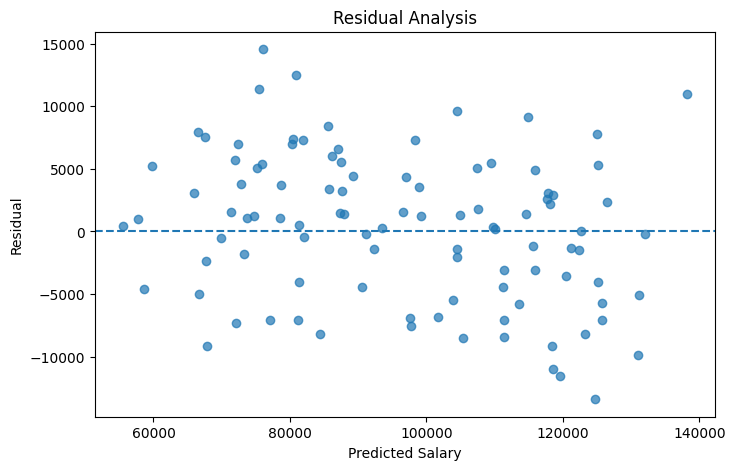

In [19]:
residuals = (
    y_test.to_numpy()
    - test_predictions
)

plt.figure(
    figsize=(8, 5)
)

plt.scatter(
    test_predictions,
    residuals,
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Predicted Salary"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Residual Analysis"
)

plt.show()

In [20]:
new_employee = pd.DataFrame([{
    "years_experience": 5,
    "education_years": 16,
    "certifications": 3,
    "projects_completed": 10
}])

predicted_salary = model.predict(
    new_employee
)[0]

print(
    f"Predicted salary: ${predicted_salary:,.2f}"
)

Predicted salary: $84,855.83


In [21]:
MODEL_PATH = (
    ARTIFACT_DIR
    / "linear_regression.joblib"
)

joblib.dump(
    model,
    MODEL_PATH
)

print(
    "Saved:",
    MODEL_PATH
)

Saved: linear_regression_artifacts/linear_regression.joblib


In [22]:
metadata = {
    "created_at":
        datetime.now().isoformat(),

    "model":
        "LinearRegression",

    "features":
        FEATURES,

    "target":
        TARGET,

    "metrics": {
        "MAE":
            float(MAE),

        "RMSE":
            float(RMSE),

        "R2":
            float(R2)
    }
}

METADATA_PATH = (
    ARTIFACT_DIR
    / "metadata.json"
)

with open(
    METADATA_PATH,
    "w"
) as file:

    json.dump(
        metadata,
        file,
        indent=4
    )

print(
    "Saved:",
    METADATA_PATH
)

Saved: linear_regression_artifacts/metadata.json


In [23]:
def smoke_test():

    assert len(data) == 500

    assert (
        data.isna()
        .sum()
        .sum()
        == 0
    )

    assert len(X_train) == 400
    assert len(X_test) == 100

    assert (
        len(model.coef_)
        == len(FEATURES)
    )

    assert np.isfinite(
        test_predictions
    ).all()

    assert MAE >= 0
    assert RMSE >= 0
    assert R2 <= 1

    assert MODEL_PATH.exists()
    assert METADATA_PATH.exists()

    loaded_model = joblib.load(
        MODEL_PATH
    )

    loaded_predictions = (
        loaded_model.predict(
            X_test
        )
    )

    assert np.allclose(
        test_predictions,
        loaded_predictions
    )

    print(
        "✅ Linear regression pipeline passed."
    )


smoke_test()

✅ Linear regression pipeline passed.
